# TLS evolution

Parameters follow the D, sigma_k and x_tls conventions. The coupling profile is `sqrt`, as in Uri's experiments.
Numerical functions live in `experiment/`; this notebook controls their inputs and displays results.
See the [mathematical and code documentation](../documentation/main.pdf).


In [1]:
from pathlib import Path
import sys

# Works whether the kernel starts at the repository root or inside notebooks/.
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / 'src' / 'xp_config.py').is_file() and (p / 'experiment').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from dataclasses import replace
import numpy as np
import pandas as pd
from IPython.display import display

# Keep small populations and norm drift visible; stored values retain full precision.
pd.set_option('display.float_format', '{:.9g}'.format)
import matplotlib.pyplot as plt
from src.xp_config import ExperimentConfig
from src.experiment import estimate_config
from src.fidelities import fidelities_over_time


## Parameters


In [2]:
CTRL_M_EXPLICIT = True
M = 5                         # Must be odd; k=0 is included.
cutoffs = {'ir_cutoff': 0.0, 'uv_cutoff': 2.0}  # Used only when control is False.

param_atom = {'omega_0': 1.0, 'D': 0.2, 'L': 2*np.pi,
              'x_tls': 0.0, 'coupling': 'sqrt', 'initial_state': 'g'}
param_photon = {'k_0': 1.0, 'sigma_k': 0.4, 'x_0': -2.0,
                'state': 'number', 'n': 1, 'alpha': 1.0}
param_time_evol = {'T': 4.0, 'dt': 0.05, 'rtol': 1e-9, 'atol': 1e-11}
n_max = 2
truncation = 'full+totalcap'
RWA = False

config = ExperimentConfig(param_photon, param_atom, param_time_evol, cutoffs,
                          n_max=n_max, truncation=truncation, RWA=RWA,
                          CTRL_M_EXPLICIT=CTRL_M_EXPLICIT, M=M)


## Resource estimates and simulation

The tables are stored as DataFrames. Memory estimates exclude sparse matrices, basis/Python objects, solver workspace and plots; `feasible` is a heuristic.


,L,delta_k,control,requested_M,requested_IR,requested_UV,n_modes,k_min,k_max,ir_effective,uv_effective,smallest_nonzero_k,zero_present,radial_cutoffs_exact,equivalent_M
grid,,,,,,,,,,,,,,,
base,6.28318531,1,explicit M,5,<NA>,<NA>,5,-2,2,0,2,1,True,True,5
selected,6.28318531,1,explicit M,5,<NA>,<NA>,5,-2,2,0,2,1,True,True,5


,basis,n_max,store_state,n_modes,dimension,n_times,ket_gib,history_gib,retained_vectors_gib,hamiltonian_nnz_bound,feasible
0,full+totalcap,2,True,5,42,81,6.2584877e-07,5.06937504e-05,0.000101387501,462,True
1,truncated,2,True,5,22,81,3.27825546e-07,2.65538692e-05,5.31077385e-05,242,True


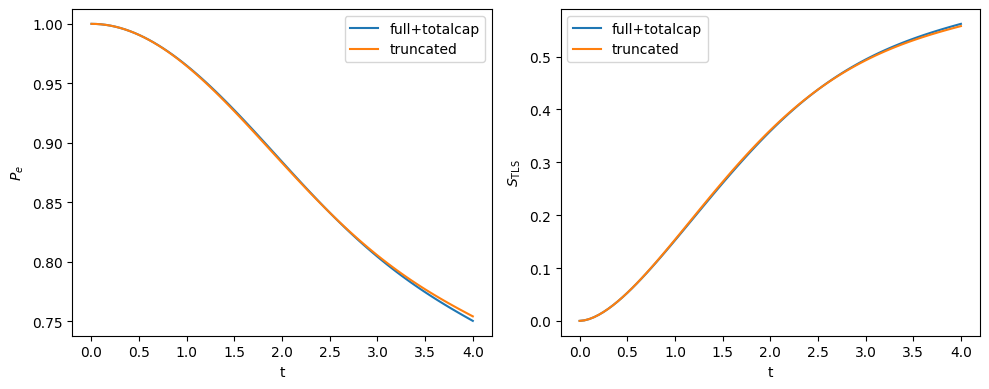

In [3]:
from experiment.atom_evolution import run_atom_evolution, plot_atom_evolution
schemes = ('full+totalcap', 'truncated')
config = replace(config, param_atom={**param_atom, 'initial_state': 'e'},
                 param_photon={**param_photon, 'n': 0})
checks = [estimate_config(replace(config, truncation=s), print_report=False) for s in schemes]
grid_table = checks[0]['grid_table']
resource_table = pd.concat([check['resource_table'] for check in checks], ignore_index=True)
display(grid_table, resource_table)
if not all(check['feasible'] for check in checks):
    raise MemoryError('Adjust the parameters after reviewing the resource estimates.')
runs = run_atom_evolution(config, schemes)
fig = plot_atom_evolution(runs)
plt.show()


## Additional diagnostics


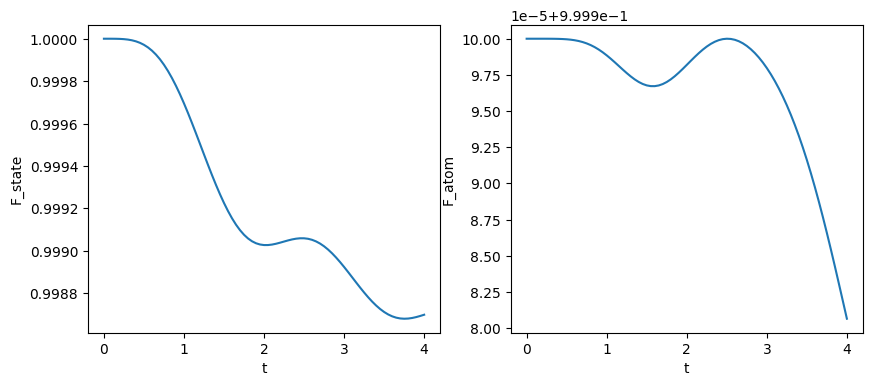

,initial,final,time_mean
fidelity,,,
F_state,1,0.998698982,0.999246101
F_atom,1,0.999980649,0.999996759


In [4]:
F = fidelities_over_time(runs['truncated'], runs['full+totalcap'])
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name in zip(axes, ('F_state', 'F_atom')):
    ax.plot(runs['truncated'].times, F[name])
    ax.set(xlabel='t', ylabel=name)
plt.show()

fidelity_history = pd.DataFrame(F, index=pd.Index(runs['truncated'].times, name='time'))
fidelity_summary = pd.DataFrame({
    'initial': {name: values[0] for name, values in F.items()},
    'final': {name: values[-1] for name, values in F.items()},
    'time_mean': {name: np.mean(values) for name, values in F.items()},
}).rename_axis('fidelity')
display(fidelity_summary)
